In [1]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = "1"
import pandas as pd
import numpy as np
import sys
from copy import deepcopy,copy
from datetime import datetime
import pickle
import sys
import matplotlib.pyplot as plt
import warnings
from scipy.signal import savgol_filter
#warnings.filterwarnings("ignore")
#warnings.filterwarnings("ignore", category=RuntimeWarning)
stderr_fileno = sys.stderr
sys.stderr = open(os.devnull, 'w')

src = os.path.dirname('/export/home/oriolca/Integral_BMS_Governing_Equations/I-BMS/')
sys.path.append(src)
from mcmc_ode import *
from parallel_ode import *

path = os.path.join(src, "Prior/")
sys.path.append(path)
from fit_prior import read_prior_par

priors = {
    "v2_p3": f"Prior/final_prior_param_sq.named_equations.nv2.np3.2016-09-09 18:49:42.927679.dat",
    "v2_p4": f"Prior/final_prior_param_sq.named_equations.nv2.np4.2016-09-09 18:49:43.056910.dat",
    "v2_p8": f"Prior/final_prior_param_sq.named_equations.nv2.np8.2016-09-09 18:49:42.800618.dat",
    "v3_p8": f"Prior/final_prior_param_sq.named_equations.nv3.np6.maxs50.2021-12-14 09:51:44.438445.dat",
}

def rossler(t, state, a=0.2, b=0.2, c=5.7):
    x, y, z = state
    dxdt = -y-z
    dydt = x+a*y
    dzdt = b + z*(x-c)
    return [dxdt, dydt, dzdt]

# Parameters
t_span = (0, 100)
t_eval = np.linspace(*t_span, 10000)  # 10k points
x0 = [1.0, 1.0, 1.0]  # initial conditions

# Integrate the Lorenz system
sol = solve_ivp(rossler, t_span, x0, t_eval=t_eval, method='RK45', rtol=1e-9, atol=1e-9)

eps = 10 ** -(40 / 20)
# Convert to a pandas DataFrame for convenience
data = pd.DataFrame({'t': sol.t, 'x': sol.y[0] + eps * np.random.normal(scale=np.std(sol.y[0]), size=sol.y[0].shape),
                     'y': sol.y[1]+ eps * np.random.normal(scale=np.std(sol.y[1]), size=sol.y[1].shape),
                     'z': sol.y[2]+ eps * np.random.normal(scale=np.std(sol.y[2]), size=sol.y[2].shape)})

print(data)

x = data[['x','y','z']]
t = pd.Series(data[['t']].t)

dt = t.to_numpy()[1] - t.to_numpy()[0]
window_length = 21    # must be odd and <= len(t)
polyorder = 2         # generally 2..5

x_hat = savgol_filter(x['x'], window_length, polyorder, delta=dt, mode='interp')
y_hat = savgol_filter(x['y'], window_length, polyorder, delta=dt, mode='interp')
z_hat = savgol_filter(x['z'], window_length, polyorder, delta=dt, mode='interp')

x_dot = savgol_filter(x['x'], window_length, polyorder, deriv=1, delta=dt, mode='interp')
y_dot = savgol_filter(x['y'], window_length, polyorder, deriv=1, delta=dt, mode='interp')
z_dot = savgol_filter(x['z'], window_length, polyorder, deriv=1, delta=dt, mode='interp')

dx = pd.DataFrame(data = {'x': x_dot, 'y': y_dot, 'z': z_dot})
dx = [pd.DataFrame(data = {'x': x_hat, 'y': y_hat, 'z':z_hat}),pd.DataFrame(data = {'x': x_dot, 'y': y_dot, 'z':z_dot})]

print(x)

print(t)

print(dx)

               t         x         y         z
0       0.000000  0.926204  0.951644  0.986480
1       0.010001  1.030441  1.080872  0.932337
2       0.020002  0.928240  0.934888  0.939483
3       0.030003  0.952991  1.069629  0.876370
4       0.040004  0.892798  1.052273  0.814539
...          ...       ...       ...       ...
9995   99.959996  9.489126 -3.841681  0.733669
9996   99.969997  9.519533 -3.791624  0.760783
9997   99.979998  9.565241 -3.610550  0.752412
9998   99.989999  9.617737 -3.661085  0.803090
9999  100.000000  9.681824 -3.559779  0.792383

[10000 rows x 4 columns]
             x         y         z
0     0.926204  0.951644  0.986480
1     1.030441  1.080872  0.932337
2     0.928240  0.934888  0.939483
3     0.952991  1.069629  0.876370
4     0.892798  1.052273  0.814539
...        ...       ...       ...
9995  9.489126 -3.841681  0.733669
9996  9.519533 -3.791624  0.760783
9997  9.565241 -3.610550  0.752412
9998  9.617737 -3.661085  0.803090
9999  9.681824 -3.559779 

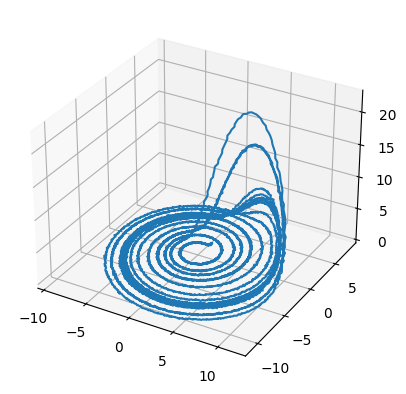

In [2]:
ax = plt.figure().add_subplot(projection='3d')
ax.plot(x['x'], x['y'], x['z'], label='parametric curve')

plt.show()

In [3]:
XLABS = ['x','y','z']
n_params = 8

path = os.path.join(src, priors[f"v{len(XLABS)}_p{str(n_params)}"])
prior_par = read_prior_par(path)

Ts=[1] + [1.04**k for k in range(1, 20)]

del prior_par['Nopi_abs']
del prior_par['Nopi2_abs']
del prior_par['Nopi_tan']
del prior_par['Nopi2_tan']
del prior_par['Nopi_sinh']
del prior_par['Nopi2_sinh']
del prior_par['Nopi_cosh']
del prior_par['Nopi2_cosh']
del prior_par['Nopi_tanh']
del prior_par['Nopi2_tanh']


OPS = {
    "sin": 1,
    "cos": 1,
    "exp": 1,
    "pow2": 1,
    "pow3": 1,
    "-": 1,
    "+": 2,
    "*": 2,
    "/": 2,
    "**": 2,
}
import time

start = time.time()
model_x = Tree(
    ops=OPS,
    variables=XLABS,
    parameters=["a%d" % i for i in range(n_params)],
    x=x, t=t, dx=dx,
    prior_par=prior_par,
    from_string = '(-y - z)'
)

print(model_x)
print(model_x.E)

model_y = Tree(
    ops=OPS,
    variables=XLABS,
    parameters=["a%d" % i for i in range(n_params)],
    x=x, t=t, dx=dx,
    prior_par=prior_par,
    from_string ='((x + (_a0_ * y))'
)
print(model_y)
print(model_y.E)

model_z = Tree(
    ops=OPS,
    variables=XLABS,
    parameters=["a%d" % i for i in range(n_params)],
    x=x, t=t, dx=dx,
    prior_par=prior_par,
    from_string ='(_a1_ + (z * (x - _a2_)))'
)
print(model_z)
print(model_z.E)


couplings=[model_x,model_y,model_z]
model_x.set_couplings(couplings)

print(model_x)
print(model_x.E)
print(model_x.par_values)
print(model_x.x0_values)

(-y - z)
<SharedNumber inf>
(x + (_a0_ * y))
<SharedNumber inf>
(_a1_ + (z * (x - _a2_)))
<SharedNumber inf>
(-y - z)
<SharedNumber 6931.6526919165935>
<SharedDict {'d0': {'_a0_': 0.20034662495443842, '_a1_': 0.2108815776808355, '_a2_': 5.711672216700015, '_a3_': 1.0, '_a4_': 1.0, '_a5_': 1.0, '_a6_': 1.0, '_a7_': 1.0}}>
<SharedDict {'d0': array([0.80701497, 1.06111309, 0.76533639])}>


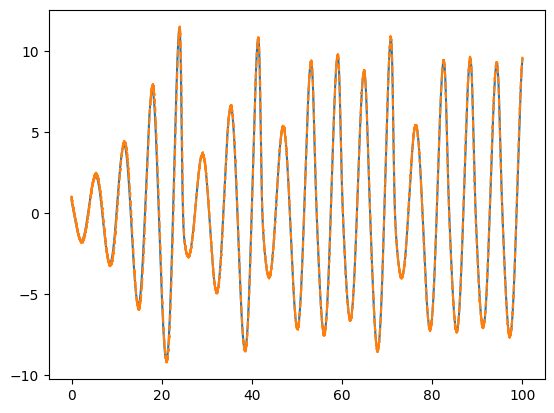

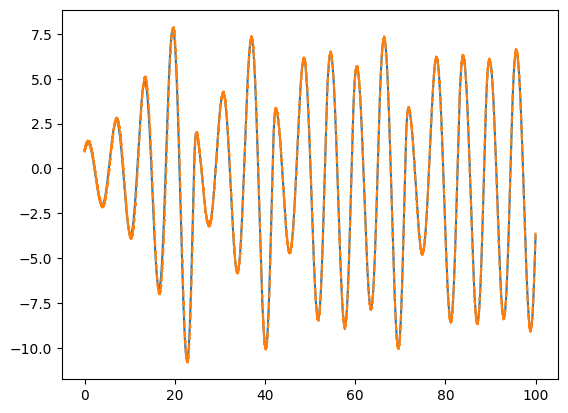

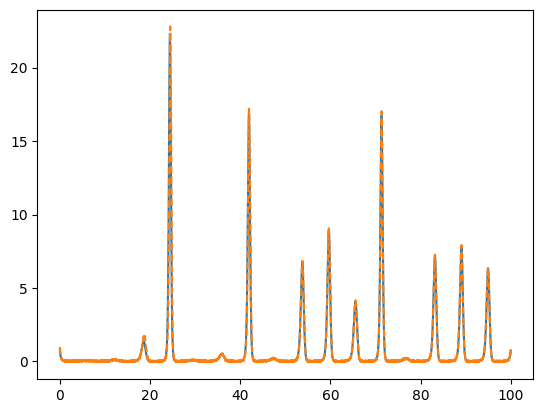

In [4]:
model_x.integrator=Integrator('rk45')
model_y.integrator=Integrator('rk45')
model_z.integrator=Integrator('rk45')
del model_x.fit_par[(str(model_x),str(model_y),str(model_z))]
model_x.get_sse(fit=True)
integral = model_x.integrate(t)

plt.plot(t,integral['d0']['x'])
plt.plot(t,x['x'],'--')
plt.show()
plt.plot(t,integral['d0']['y'])
plt.plot(t,x['y'],'--')
plt.show()
plt.plot(t,integral['d0']['z'])
plt.plot(t,x['z'],'--')
plt.show()

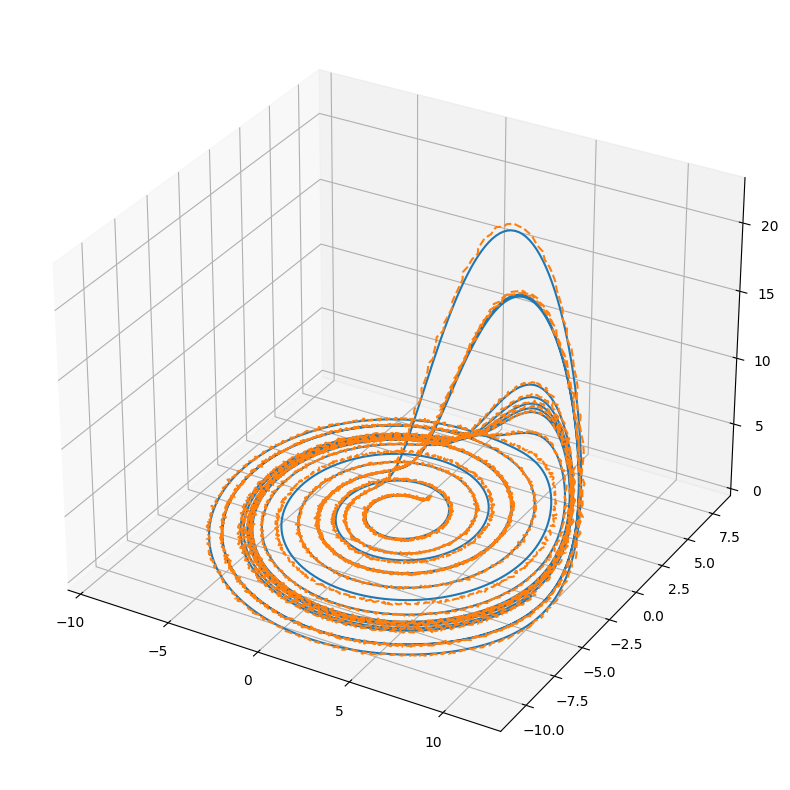

In [5]:
ax = plt.figure(figsize=(10,10)).add_subplot(projection='3d')
ax.plot(integral['d0']['x'], integral['d0']['y'], integral['d0']['z'], label='parametric curve')
ax.plot(x['x'], x['y'], x['z'],'--', label='parametric curve')

plt.show()

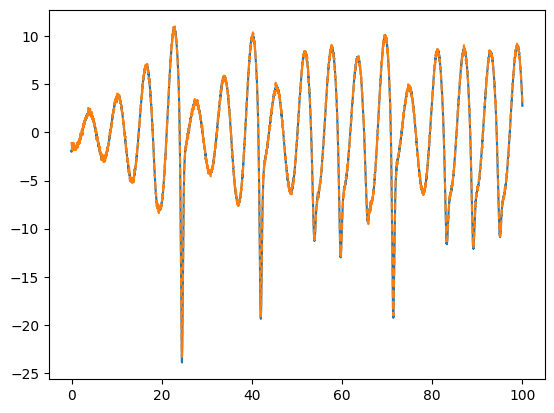

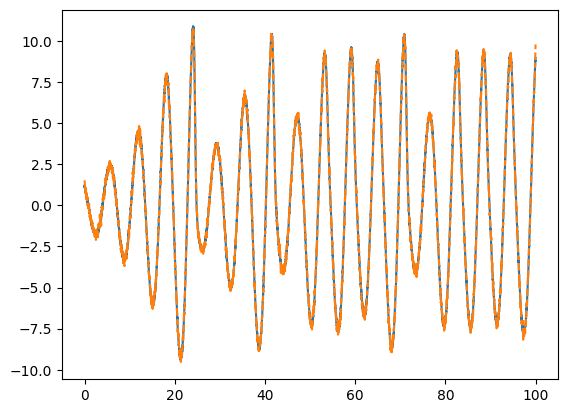

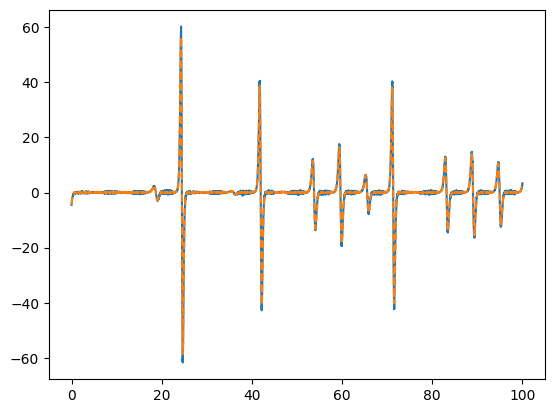

In [6]:
dx_pred = model_x.predict(x)

plt.plot(t,dx_pred['x'])
plt.plot(t,dx[1]['x'],'--')
plt.show()
plt.plot(t,dx_pred['y'])
plt.plot(t,dx[1]['y'],'--')
plt.show()
plt.plot(t,dx_pred['z'])
plt.plot(t,dx[1]['z'],'--')
plt.show()